In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Les 3 Métriques Clés du Clustering


**A. Score de Silhouette (Silhouette Score)**

Il mesure si un point est proche de son propre groupe et loin des autres.

* 1 : Groupes parfaits.

* 0 : Groupes qui se chevauchent.

* -1 : Mauvaise affectation.

$$ S = \frac{b - a}{\max(a, b)} $$

(où a est la distance moyenne intra-groupe et b la distance avec le groupe le plus proche).

**B. Méthode du Coude (Elbow Method / Inertee)**

On calcule la Somme des Carrés Intra-cluster (Inertia). Plus elle est faible, plus les groupes sont denses. On cherche le "coude" sur le graphique.

$$ \text{Inertia} = \sum_{i=0}^{n} \min_{\mu_j \in C} (||x_i - \mu_j||^2) $$

**C. Indice de Calinski-Harabasz**

Il évalue le rapport entre la dispersion entre les groupes et la dispersion à l'intérieur des groupes. Plus il est élevé, mieux c'est.

**D. Le Score de Davies-Bouldin**

Elle mesure le rapport entre la distance "intra-cluster" et la distance "inter-cluster".
La règle est inverse : Plus le score est bas, meilleur est le clustering.


# Application :

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Chargement (Vérifie bien le chemin vers le .csv)
df = pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')
df.head()
df.describe()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


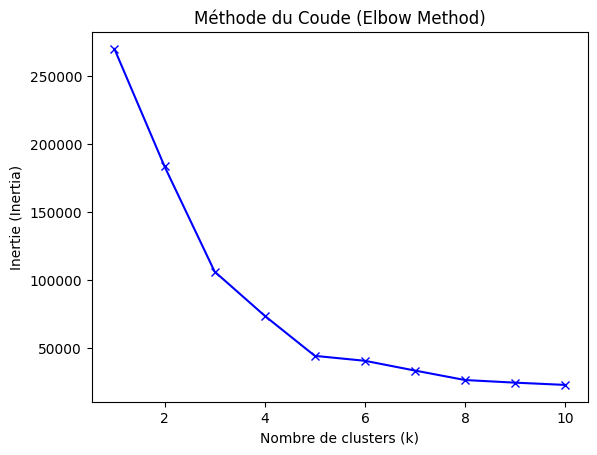

In [4]:
# 2. On garde seulement 'Annual Income' et 'Spending Score' pour visualiser
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# 3. Trouver le nombre optimal de clusters (Elbow Method)

inertia = []
# liste pour stocker les inerties 

K_range = range(1, 11)
# la plage de test 

for k in K_range:
    #initialisation
    kmeans = KMeans(n_clusters=k, random_state=42) # on essaye de diviser les clients en k groupes
    #entrainement 
    kmeans.fit(X) #l'algorithme déplace les centres des groupes pour minimiser la distance avec les clients.
    #recupération des inerties 
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie (Inertia)')
plt.title('Méthode du Coude (Elbow Method)')
plt.show()

L'Inertie diminue toujours quand k augmente (si on a autant de groupes que de clients, l'inertie est de 0, mais c'est inutile).

Le Coude (Elbow) est le point de rupture : c'est l'endroit où ajouter un groupe supplémentaire n'apporte plus une amélioration significative de la précision. C'est le compromis idéal entre simplicité et précision. ici c'est **k = 5**.


Silhouette Score pour 5 clusters : 0.554


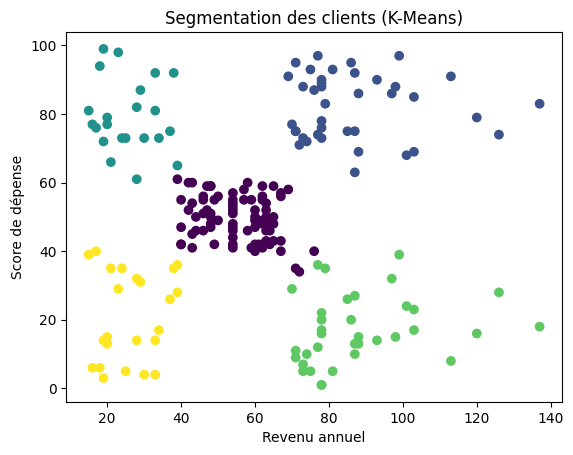

In [14]:
# On choisit k=5
# j'ai essayé de changer n_clusters dans [1,10] et pour 5 on a la meilleure valeur 
model = KMeans(n_clusters=5, random_state=42)
clusters = model.fit_predict(X)

# Calcul du score
score = silhouette_score(X, clusters)
#Cette fonction calcule si les clients sont bien rangés. 
#Elle compare la distance d'un point avec son propre groupe (Cohesion) par rapport aux autres groupes (Separation).
print(f"Silhouette Score pour 5 clusters : {score:.3f}")

# Visualisation des groupes
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=clusters, cmap='viridis')
plt.title('Segmentation des clients (K-Means)')
plt.xlabel('Revenu annuel')
plt.ylabel('Score de dépense')
plt.show()

# Hard Clustering vs Soft Clustering

Le K-Means (qu'on va d'utiliser la haut) est un algorithme de **Hard Clustering**.

**Hard Clustering :** Chaque point appartient à un seul groupe (100% dans le groupe A, 0% dans le B).

**Soft Clustering :** Chaque point a une probabilité d'appartenir à chaque groupe (ex: 80% de chances d'être dans le groupe A et 20% dans le B). C'est beaucoup plus réaliste pour des clients qui ont des comportements mixtes.

# DBSCAN : L'alternative au K-Means

Le K-Means cherche toujours des formes circulaires. Mais dans la vraie vie, les groupes peuvent avoir des formes bizarres (croissants, anneaux, etc.).

DBSCAN n'a pas besoin que tu lui dises combien de clusters créer (k).

Il cherche des zones de haute densité.

Il identifie automatiquement les Outliers (les points isolés qui ne ressemblent à rien).


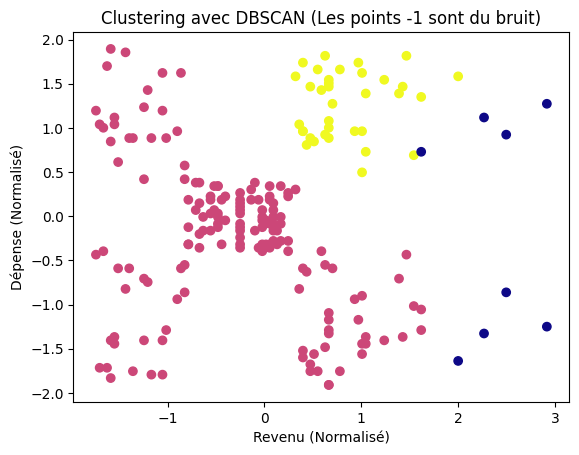

Silhouette Score pour 5 clusters : 0.555
Nombre de clusters estimés : 2
Nombre de points bruyants (Outliers) : 8


In [16]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. IMPORTANT : DBSCAN est très sensible aux échelles. On doit normaliser.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Configuration de DBSCAN
# eps : la distance maximale entre deux points pour qu'ils soient voisins
# min_samples : le nombre minimum de points pour former un groupe dense
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters_db = dbscan.fit_predict(X_scaled)

# 3. Visualisation
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_db, cmap='plasma')
plt.title('Clustering avec DBSCAN (Les points -1 sont du bruit)')
plt.xlabel('Revenu (Normalisé)')
plt.ylabel('Dépense (Normalisé)')
plt.show()

# Compter le nombre de clusters (en excluant le bruit -1)
n_clusters_ = len(set(clusters_db)) - (1 if -1 in clusters_db else 0)
n_noise_ = list(clusters_db).count(-1)

score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score pour 5 clusters : {score:.3f}")
print(f'Nombre de clusters estimés : {n_clusters_}')
print(f'Nombre de points bruyants (Outliers) : {n_noise_}')